<a href="https://colab.research.google.com/github/aren4/Kambo/blob/main/Kambo_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import textwrap
from joblib import Parallel, delayed

# Set pandas to display all columns
pd.set_option('display.max_columns', None)

df = pd.read_csv('/content/drive/MyDrive/Kambo/Kambo_imputed.csv', index_col=False)
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('.', '_')
columns_to_drop = ['Unnamed:_0']
df.drop(columns=columns_to_drop, inplace=True)
df.head()

,AnonID,Phase,DEMO_Days_btwn,DEMO_Autoimmu,PRE_MAAS_Total,PRE_RYFF_Total,PRE_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,PRE_MFI_General_Fatigue_Score,PRE_MFI_Physical_Fatigue_Score,PRE_MFI_Reduced_Activity_Score,PRE_MFI_Reduced_Motivation_Score,PRE_MFI_Mental_Fatigue_Score,PRE_MFI_TotalScore,PRE_IDS_TotalScore,PRE_SHS_TotalScore,PRE_BPI_PainSeverityIndex,PRE_BPI_PainInterferenceIndex,PRE_BPI_PainReliefPercent,DEMO_Session1_head,DEMO_Session1_neck,DEMO_Session1_thorax,DEMO_Session1_abdomen,DEMO_Session1_pelvis,DEMO_Session1_upper_extremity,DEMO_Session1_lower_extremity,DEMO_Session2_head,DEMO_Session2_neck,DEMO_Session2_thorax,DEMO_Session2_abdomen,DEMO_Session2_pelvis,DEMO_Session2_upper_extremity,DEMO_Session2_lower_extremity,DEMO_Session3_head,DEMO_Session3_neck,DEMO_Session3_thorax,DEMO_Session3_abdomen,DEMO_Session3_pelvis,DEMO_Session3_upper_extremity,DEMO_Session3_lower_extremity,DEMO_Private_or_group_1_NUM,DEMO_Private_or_group_2_NUM,DEMO_Private_or_group_3_NUM,DEMO_Vomit_1_NUM,DEMO_Vomit_2_NUM,DEMO_Vomit_3_NUM,DEMO_BM_1_NUM,DEMO_BM_2_NUM,DEMO_BM_3_NUM,DEMO_Fainting_1_NUM,DEMO_Fainting_2_NUM,DEMO_Fainting_3_NUM,DEMO_Rapeh_1_NUM,DEMO_Rapeh_2_NUM,DEMO_Rapeh_3_NUM,DEMO_Sananga_1_NUM,DEMO_Sananga_2_NUM,DEMO_Sananga_3_NUM,DEMO_Age,DEMO_Sex,DEMO_Gender,DEMO_Education,DEMO_Income,DEMO_Height_in,DEMO_Weight_lb,DEMO_Lyme_DX,DEMO_Post_Lyme_DX,DEMO_Psychedelic_Use,DEMO_Cannabis_Use,DEMO_Nervous,DEMO_Excited,DEMO_BMI,MAAS_Total_POST,RYFF_Total_POST,RYFF_Autonomy_Score_POST,RYFF_EnvironmentalMastery_Score_POST,RYFF_PersonalGrowth_Score_POST,RYFF_PositiveRelations_Score_POST,RYFF_PurposeInLife_Score_POST,RYFF_SelfAcceptance_Score_POST,MFI_General_Fatigue_Score_POST,MFI_Physical_Fatigue_Score_POST,MFI_Reduced_Activity_Score_POST,MFI_Reduced_Motivation_Score_POST,MFI_Mental_Fatigue_Score_POST,MFI_TotalScore_POST,IDS_TotalScore_POST,SHS_TotalScore_POST,BPI_PainSeverityIndex_POST,BPI_PainInterferenceIndex_POST,BPI_PainReliefPercent_POST,MEQ30_Ineffability_POST,MEQ30_MysticalExperience_POST,MEQ30_PositiveMood_POST,MEQ30_TranscendenceOfTimeAndSpace_POST,MEQ30_TotalScore_POST,CEQ30_Isolation_SUM_POST,CEQ30_Fear_SUM_POST,CEQ30_Grief_SUM_POST,CEQ30_Insanity_SUM_POST,CEQ30_Death_SUM_POST,CEQ30_Paranoia_SUM_POST,CEQ30_PhysicalDistress_SUM_POST,CEQ30_Total_SUM_POST,5DASC_TotalScore_POST,5DASC_OceanicBoundlessness_Score_POST,5DASC_AnxiousEgoDissolution_Score_POST,5DASC_VisionaryRestructuralization_Score_POST,5DASC_AuditoryAlterations_Score_POST,5DASC_ReductionOfVigilance_Score_POST,MAAS_Total_3MONTHSPOST,RYFF_Total_3MONTHSPOST,RYFF_Autonomy_Score_3MONTHSPOST,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,RYFF_PersonalGrowth_Score_3MONTHSPOST,RYFF_PositiveRelations_Score_3MONTHSPOST,RYFF_PurposeInLife_Score_3MONTHSPOST,RYFF_SelfAcceptance_Score_3MONTHSPOST,MFI_General_Fatigue_Score_3MONTHSPOST,MFI_Physical_Fatigue_Score_3MONTHSPOST,MFI_Reduced_Activity_Score_3MONTHSPOST,MFI_Reduced_Motivation_Score_3MONTHSPOST,MFI_Mental_Fatigue_Score_3MONTHSPOST,MFI_TotalScore_3MONTHSPOST,IDS_TotalScore_3MONTHSPOST,SHS_TotalScore_3MONTHSPOST,BPI_PainSeverityIndex_3MONTHSPOST,BPI_PainInterferenceIndex_3MONTHSPOST,BPI_PainReliefPercent_3MONTHSPOST
0,P001,1,28.0,1.0,3.4,4.97619,5.428571,4.857143,5.857143,4.571429,4.000000,5.142857,2.25,4.25,4.25,4.00,3.0,3.55,18.0,4.5,2.333333,1.285714,90.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.938894e-18,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.775558e-17,0.0,0.0,-3.469447e-18,-3.469447e-18,0.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0,0.0,0.0,3.0,2.0,63.0,119.0,0.0,6.938894e-18,1.0,2.0,6.0,8.0,21.079670,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,P001,2,28.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

In [33]:
# Create lists of columns
demo_cols = [col for col in df.columns if col.startswith("DEMO_")]
pre_cols = [col for col in df.columns if col.startswith("PRE_")]
post_cols = [col for col in df.columns if col.endswith("_POST")]
three_month_cols = [col for col in df.columns if col.endswith("_3MONTHSPOST")]

# Get ID and Phase columns
id_cols = ['AnonID', 'Phase']

# Function to extract and relabel columns per phase
def extract_phase(df, phase, prefix_map):
    df_phase = df[df['Phase'] == phase].copy()
    df_out = df_phase[['AnonID']].copy()
    for original_col, new_prefix in prefix_map.items():
        subset = [col for col in df.columns if col.startswith(original_col)]
        for col in subset:
            if col in df_phase.columns:
                clean_col = col.replace(original_col, "")
                df_out[f"{new_prefix}{clean_col}"] = df_phase[col].values
    return df_out

# Extract demographic/session features once from Phase 1
df_demo = df[df['Phase'] == 1][['AnonID'] + demo_cols].copy()

# Extract phase-tagged features using simple filters
df_pre = df[df['Phase'] == 1][['AnonID'] + pre_cols].copy().set_index('AnonID')

df_post = df[df['Phase'] == 2][['AnonID'] + post_cols].copy().set_index('AnonID')

df_3mo = df[df['Phase'] == 3][['AnonID'] + three_month_cols].copy().set_index('AnonID')

# Combine all data into one wide-format dataframe
df_wide = df_demo.set_index('AnonID').join(df_pre, how='outer', rsuffix='_PRE')
df_wide = df_wide.join(df_post, how='outer')
df_wide = df_wide.join(df_3mo, how='outer')
df_wide.reset_index(inplace=True)

df_wide.head()

,AnonID,DEMO_Days_btwn,DEMO_Autoimmu,DEMO_Session1_head,DEMO_Session1_neck,DEMO_Session1_thorax,DEMO_Session1_abdomen,DEMO_Session1_pelvis,DEMO_Session1_upper_extremity,DEMO_Session1_lower_extremity,DEMO_Session2_head,DEMO_Session2_neck,DEMO_Session2_thorax,DEMO_Session2_abdomen,DEMO_Session2_pelvis,DEMO_Session2_upper_extremity,DEMO_Session2_lower_extremity,DEMO_Session3_head,DEMO_Session3_neck,DEMO_Session3_thorax,DEMO_Session3_abdomen,DEMO_Session3_pelvis,DEMO_Session3_upper_extremity,DEMO_Session3_lower_extremity,DEMO_Private_or_group_1_NUM,DEMO_Private_or_group_2_NUM,DEMO_Private_or_group_3_NUM,DEMO_Vomit_1_NUM,DEMO_Vomit_2_NUM,DEMO_Vomit_3_NUM,DEMO_BM_1_NUM,DEMO_BM_2_NUM,DEMO_BM_3_NUM,DEMO_Fainting_1_NUM,DEMO_Fainting_2_NUM,DEMO_Fainting_3_NUM,DEMO_Rapeh_1_NUM,DEMO_Rapeh_2_NUM,DEMO_Rapeh_3_NUM,DEMO_Sananga_1_NUM,DEMO_Sananga_2_NUM,DEMO_Sananga_3_NUM,DEMO_Age,DEMO_Sex,DEMO_Gender,DEMO_Education,DEMO_Income,DEMO_Height_in,DEMO_Weight_lb,DEMO_Lyme_DX,DEMO_Post_Lyme_DX,DEMO_Psychedelic_Use,DEMO_Cannabis_Use,DEMO_Nervous,DEMO_Excited,DEMO_BMI,PRE_MAAS_Total,PRE_RYFF_Total,PRE_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,PRE_MFI_General_Fatigue_Score,PRE_MFI_Physical_Fatigue_Score,PRE_MFI_Reduced_Activity_Score,PRE_MFI_Reduced_Motivation_Score,PRE_MFI_Mental_Fatigue_Score,PRE_MFI_TotalScore,PRE_IDS_TotalScore,PRE_SHS_TotalScore,PRE_BPI_PainSeverityIndex,PRE_BPI_PainInterferenceIndex,PRE_BPI_PainReliefPercent,MAAS_Total_POST,RYFF_Total_POST,RYFF_Autonomy_Score_POST,RYFF_EnvironmentalMastery_Score_POST,RYFF_PersonalGrowth_Score_POST,RYFF_PositiveRelations_Score_POST,RYFF_PurposeInLife_Score_POST,RYFF_SelfAcceptance_Score_POST,MFI_General_Fatigue_Score_POST,MFI_Physical_Fatigue_Score_POST,MFI_Reduced_Activity_Score_POST,MFI_Reduced_Motivation_Score_POST,MFI_Mental_Fatigue_Score_POST,MFI_TotalScore_POST,IDS_TotalScore_POST,SHS_TotalScore_POST,BPI_PainSeverityIndex_POST,BPI_PainInterferenceIndex_POST,BPI_PainReliefPercent_POST,MEQ30_Ineffability_POST,MEQ30_MysticalExperience_POST,MEQ30_PositiveMood_POST,MEQ30_TranscendenceOfTimeAndSpace_POST,MEQ30_TotalScore_POST,CEQ30_Isolation_SUM_POST,CEQ30_Fear_SUM_POST,CEQ30_Grief_SUM_POST,CEQ30_Insanity_SUM_POST,CEQ30_Death_SUM_POST,CEQ30_Paranoia_SUM_POST,CEQ30_PhysicalDistress_SUM_POST,CEQ30_Total_SUM_POST,5DASC_TotalScore_POST,5DASC_OceanicBoundlessness_Score_POST,5DASC_AnxiousEgoDissolution_Score_POST,5DASC_VisionaryRestructuralization_Score_POST,5DASC_AuditoryAlterations_Score_POST,5DASC_ReductionOfVigilance_Score_POST,MAAS_Total_3MONTHSPOST,RYFF_Total_3MONTHSPOST,RYFF_Autonomy_Score_3MONTHSPOST,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,RYFF_PersonalGrowth_Score_3MONTHSPOST,RYFF_PositiveRelations_Score_3MONTHSPOST,RYFF_PurposeInLife_Score_3MONTHSPOST,RYFF_SelfAcceptance_Score_3MONTHSPOST,MFI_General_Fatigue_Score_3MONTHSPOST,MFI_Physical_Fatigue_Score_3MONTHSPOST,MFI_Reduced_Activity_Score_3MONTHSPOST,MFI_Reduced_Motivation_Score_3MONTHSPOST,MFI_Mental_Fatigue_Score_3MONTHSPOST,MFI_TotalScore_3MONTHSPOST,IDS_TotalScore_3MONTHSPOST,SHS_TotalScore_3MONTHSPOST,BPI_PainSeverityIndex_3MONTHSPOST,BPI_PainInterferenceIndex_3MONTHSPOST,BPI_PainReliefPercent_3MONTHSPOST
0,P001,28.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.938894e-18,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.775558e-17,0.0,0.0,-3.469447e-18,-3.469447e-18,0.0,1.0,1.0,1.0,1.0,1.0,1.0,28.0,0.0,0.0,3.0,2.0,63.0,119.0,0.0,6.938894e-18,1.0,2.0,6.0,8.0,21.079670,3.400000,4.976190,5.428571,4.857143,5.857143,4.571429,4.000000,5.142857,2.25,4.25,4.25,4.00,3.00,3.55,18.0,4.50,2.333333,1.285714,90.000000,3.200000,5.536585,6.000000,6.000000,6.166667,4.857143,4.571429,5.714286,2.50,4.50,4.50,4.25,3.25,3.80,13.0,5.00,4.058241,2.066249,42.829302,0.666667,1.466667,1.500000,0.666667,1.075000,0.0,0.25,0.4,0.0,0.0,0.0,1.333333,0.283333,31.253333,70.6,0.000,54.833333,10.833333,20.000,2.466

In [19]:
df_wide.to_csv("df_wide.csv", index=False)

In [34]:
# Reload dataset
df = df_wide.copy()

# Recalculate outcome deltas
df['PrePost_Delta_MAAS'] = df['MAAS_Total_POST'] - df['PRE_MAAS_Total']
df['PrePost_Delta_MFI'] = df['MFI_TotalScore_POST'] - df['PRE_MFI_TotalScore']
df['PrePost_Delta_IDSSR'] = df['IDS_TotalScore_POST'] - df['PRE_IDS_TotalScore']
df['Pre3MoPost_Delta_MAAS'] = df['MAAS_Total_3MONTHSPOST'] - df['PRE_MAAS_Total']
df['Pre3MoPost_Delta_MFI'] = df['MFI_TotalScore_3MONTHSPOST'] - df['PRE_MFI_TotalScore']
df['Pre3MoPost_Delta_IDSSR'] = df['IDS_TotalScore_3MONTHSPOST'] - df['PRE_IDS_TotalScore']
df['Pre3MoPost_Delta_RYFF_Total_Score'] = df['RYFF_Total_3MONTHSPOST'] - df['PRE_RYFF_Total']
df['PrePost_Delta_SHS'] = df['SHS_TotalScore_POST'] - df['PRE_SHS_TotalScore']
df['Pre3MoPost_Delta_SHS'] = df['SHS_TotalScore_3MONTHSPOST'] - df['PRE_SHS_TotalScore']


# Include Ryff subscales and deltas
ryff_subscales = [
    'RYFF_Autonomy_Score', 'RYFF_EnvironmentalMastery_Score', 'RYFF_PersonalGrowth_Score',
    'RYFF_PositiveRelations_Score', 'RYFF_PurposeInLife_Score', 'RYFF_SelfAcceptance_Score'
]

for sub in ryff_subscales:
    df[f'PrePost_Delta_{sub}'] = df[f'{sub}_POST'] - df[f'PRE_{sub}']
    df[f'Pre3MoPost_Delta_{sub}'] = df[f'{sub}_3MONTHSPOST'] - df[f'PRE_{sub}']

# Preview rows for inspection
preview_cols = [
    'AnonID',
    'PRE_MAAS_Total', 'MAAS_Total_3MONTHSPOST', 'Pre3MoPost_Delta_MAAS',
    'PRE_MFI_TotalScore', 'MFI_TotalScore_3MONTHSPOST', 'Pre3MoPost_Delta_MFI',
    'PRE_IDS_TotalScore', 'IDS_TotalScore_3MONTHSPOST', 'Pre3MoPost_Delta_IDSSR'
]

for sub in ryff_subscales:
    preview_cols += [f'PRE_{sub}', f'{sub}_3MONTHSPOST', f'Pre3MoPost_Delta_{sub}']

df_preview = df[preview_cols].head(10)

df_preview


,AnonID,PRE_MAAS_Total,MAAS_Total_3MONTHSPOST,Pre3MoPost_Delta_MAAS,PRE_MFI_TotalScore,MFI_TotalScore_3MONTHSPOST,Pre3MoPost_Delta_MFI,PRE_IDS_TotalScore,IDS_TotalScore_3MONTHSPOST,Pre3MoPost_Delta_IDSSR,PRE_RYFF_Autonomy_Score,RYFF_Autonomy_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_Autonomy_Score,PRE_RYFF_EnvironmentalMastery_Score,RYFF_EnvironmentalMastery_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_EnvironmentalMastery_Score,PRE_RYFF_PersonalGrowth_Score,RYFF_PersonalGrowth_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PersonalGrowth_Score,PRE_RYFF_PositiveRelations_Score,RYFF_PositiveRelations_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PositiveRelations_Score,PRE_RYFF_PurposeInLife_Score,RYFF_PurposeInLife_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_PurposeInLife_Score,PRE_RYFF_SelfAcceptance_Score,RYFF_SelfAcceptance_Score_3MONTHSPOST,Pre3MoPost_Delta_RYFF_SelfAcceptance_Score
0,P001,3.400000,2.466667,-0.933333,3.55,3.80,0.25,18.0,11.0,-7.0,5.428571,5.857143,0.428571,4.857143,5.285714,0.428571,5.857143,5.285714,-0.571429,4.571429,5.000000,0.428571,4.000000,4.000000,0.000000,5.142857,4.000000,-1.142857
1,P002,3.600000,3.533333,-0.066667,1.85,1.70,-0.15,39.0,43.0,4.0,2.714286,3.857143,1.142857,2.857143,3.714286,0.857143,3.714286,3.142857,-0.571429,5.000000,3.571429,-1.428571,5.428571,4.714286,-0.714286,4.142857,3.714286,-0.428571
2,P003,4.266667,3.133333,-1.133333,2.30,3.65,1.35,43.0,35.0,-8.0,5.428571,5.571429,0.142857,4.000000,4.142857,0.142857,4.285714,5.571429,1.285714,3.857143,4.142857,0.285714,4.571429,4.571429,0.000000,4.142857,5.000000,0.857143
3,P004,3.466667,3.133333,-0.333333,3.90,3.80,-0.10,33.0,25.0,-8.0,4.000000,4.428571,0.428571,5.000000,5.857143,0.857143,5.000000,5.285714,0.285714,4.000000,4.000000,0.000000,5.142857,4.714286,-0.428571,4.285714,4.285714,0.000000
4,P005,2.333333,1.333333,-1.000000,3.70,4.60,0.90,12.0,6.0,-6.0,5.714286,5.714286,0.000000,6.142857,6.142857,0.000000,5.285714,5.571429,0.285714,4.285714,4.857143,0.571429,4.142857,4.142857,0.000000,4.571429,5.428571,0.857143
5,P006,3.600000,4.600000,1.000000,2.50,2.55,0.05,21.0,30.0,9.0,4.285714,4.000000,-0.285714,5.000000,3.428571,-1.571429,5.142857,4.857143,-0.285714,4.571429,4.142857,-0.428571,3.857143,4.285714,0.428571,4.857143,4.285714,-0.571429
6,P007,3.133333,2.266667,-0.866667,3.00,3.80,0.80,17.0,7.0,-10.0,5.714286,6.285714,0.571429,5.285714,5.142857,-0.142857,5.000000,6.285714,1.285714,4.571429,5.142857,0.571429,5.000000,3.571429,-1.428571,3.714286,5.428571,1.714286
7,P008,2.933333,2.400000,-0.533333,3.70,4.45,0.75,13.0,9.0,-4.0,5.285714,5.714286,0.428571,5.142857,5.571429,0.428571,5.428571,5.428571,0.000000,4.142857,4.142857,0.000000,5.571429,4.714286,-0.857143,3.857143,4.142857,0.285714
8,P009,3.866667,3.466667,-0.400000,3.80,3.70,-0.10,28.0,29.0,1.0,5.714286,6.000000,0.285714,5.000000,5.428571,0.428571,4.857143,4.428571,-0.428571,5.142857,5.142857,0.000000,4.000000,3.857143,-0.142857,4.285714,4.428571,0.142857
9,P010,5.466667,3.800000,-1.666667,2.05,4.50,2.45,40.0,5.0,-35.0,4.000000,6.500000,2.500000,4.571429,6.428571,1.857143,5.857143,5.571429,-0.285714,4.000000,5.000000,1.000000,4.571429,3.714286,-0.857143,5.428571,5.571429,0.142857


In [21]:
df.to_csv("df_deltas.csv", index=False)

{'MAAS Responder': np.int64(2),
 'MFI Improved': np.int64(14),
 'Global Ryff Responder': np.int64(21)}

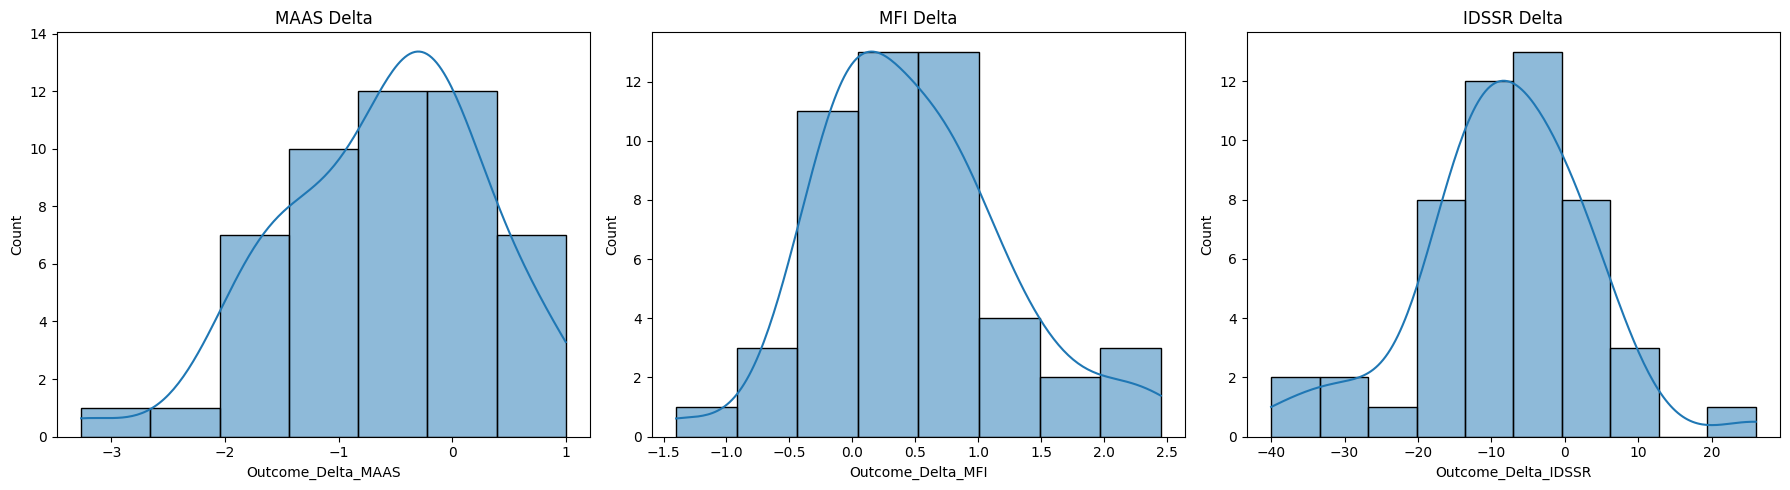

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Rename deltas to match new naming scheme
df['Outcome_Delta_MAAS'] = df['Pre3MoPost_Delta_MAAS']
df['Outcome_Delta_MFI'] = df['Pre3MoPost_Delta_MFI']
df['Outcome_Delta_IDSSR'] = df['Pre3MoPost_Delta_IDSSR']
df['Outcome_Delta_SHS'] = df['Pre3MoPost_Delta_SHS']

# Binary outcomes
maas_threshold = df['Outcome_Delta_MAAS'].std()
df['Responder_MAAS'] = (df['Outcome_Delta_MAAS'] >= maas_threshold).astype(int)
df['Responder_MFI'] = (df['Outcome_Delta_MFI'] < 0).astype(int)

# Define global PWB improvement: 4+ of 6 Ryff subscales improved
ryff_subscales = [
    'RYFF_Autonomy_Score', 'RYFF_EnvironmentalMastery_Score', 'RYFF_PersonalGrowth_Score',
    'RYFF_PositiveRelations_Score', 'RYFF_PurposeInLife_Score', 'RYFF_SelfAcceptance_Score'
]
ryff_deltas = [f'Pre3MoPost_Delta_{sub}' for sub in ryff_subscales]
df['Responder_Global_Ryff'] = (df[ryff_deltas].gt(0).sum(axis=1) >= 4).astype(int)

# Summary
outcome_summary = {
    'MAAS Responder': df['Responder_MAAS'].sum(),
    'MFI Improved': df['Responder_MFI'].sum(),
    'Global Ryff Responder': df['Responder_Global_Ryff'].sum()
}

# Outcome DataFrame
df_outcomes = df[[
    'AnonID', 'Outcome_Delta_MAAS', 'Outcome_Delta_MFI', 'Outcome_Delta_IDSSR',
    'Responder_MAAS', 'Responder_MFI', 'Responder_Global_Ryff'
]]

# Plot deltas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df['Outcome_Delta_MAAS'], ax=axes[0], kde=True).set(title='MAAS Delta')
sns.histplot(df['Outcome_Delta_MFI'], ax=axes[1], kde=True).set(title='MFI Delta')
sns.histplot(df['Outcome_Delta_IDSSR'], ax=axes[2], kde=True).set(title='IDSSR Delta')
plt.tight_layout()

outcome_summary

In [23]:
df_outcomes.to_csv("df_outcomes.csv", index=False)

In [36]:
# Get all column names
tagged_columns = df.columns.tolist()

# Identify leakage columns using updated naming
leakage_cols = [col for col in tagged_columns if (
    col.startswith("MAAS_Total_POST") or
    col.startswith("MFI_TotalScore_POST") or
    (col.startswith("MFI") and "_POST" in col) or
    col.startswith("IDS_TotalScore_POST") or
    col.startswith("RYFF_Total_POST") or
    (col.startswith("RYFF") and "_POST" in col) or
    col.startswith("SHS_TotalScore_POST") or
    (col.startswith("BPI_") and "_POST" in col) or
    col.endswith("_3MONTHSPOST") or
    (any(prefix in col for prefix in ["MEQ30_", "CEQ30_", "5DASC_"]) and "_POST" in col)
)]

# Also include deltas and responder flags
leakage_cols += [col for col in tagged_columns if any(k in col for k in ['PrePost_Delta_', 'Pre3MoPost_Delta_', 'Post3MoPost_Delta_', 'Outcome_Delta_', 'Responder_', 'Change_', 'DELTA_', 'delta_', 'Outcome_'])]

# Deduplicate and sort
leakage_cols = sorted(set(leakage_cols))

leakage_cols


['5DASC_AnxiousEgoDissolution_Score_POST',
 '5DASC_AuditoryAlterations_Score_POST',
 '5DASC_OceanicBoundlessness_Score_POST',
 '5DASC_ReductionOfVigilance_Score_POST',
 '5DASC_TotalScore_POST',
 '5DASC_VisionaryRestructuralization_Score_POST',
 'BPI_PainInterferenceIndex_3MONTHSPOST',
 'BPI_PainInterferenceIndex_POST',
 'BPI_PainReliefPercent_3MONTHSPOST',
 'BPI_PainReliefPercent_POST',
 'BPI_PainSeverityIndex_3MONTHSPOST',
 'BPI_PainSeverityIndex_POST',
 'CEQ30_Death_SUM_POST',
 'CEQ30_Fear_SUM_POST',
 'CEQ30_Grief_SUM_POST',
 'CEQ30_Insanity_SUM_POST',
 'CEQ30_Isolation_SUM_POST',
 'CEQ30_Paranoia_SUM_POST',
 'CEQ30_PhysicalDistress_SUM_POST',
 'CEQ30_Total_SUM_POST',
 'IDS_TotalScore_3MONTHSPOST',
 'IDS_TotalScore_POST',
 'MAAS_Total_3MONTHSPOST',
 'MAAS_Total_POST',
 'MEQ30_Ineffability_POST',
 'MEQ30_MysticalExperience_POST',
 'MEQ30_PositiveMood_POST',
 'MEQ30_TotalScore_POST',
 'MEQ30_TranscendenceOfTimeAndSpace_POST',
 'MFI_General_Fatigue_Score_3MONTHSPOST',
 'MFI_General_Fati

In [25]:
# --- Load label map ---
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv', index_col=False)
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

def parallel_permutation_importance(rf, X, y, n_repeats=30):
    def single_permutation(seed):
        result = permutation_importance(rf, X, y, n_repeats=n_repeats, random_state=seed)
        return result.importances_mean, result.importances_std
    seeds = np.random.randint(0, 1e6, size=10)
    results = Parallel(n_jobs=-1)(delayed(single_permutation)(seed) for seed in seeds)
    means = np.mean([r[0] for r in results], axis=0)
    stds = np.mean([r[1] for r in results], axis=0)
    return means, stds

def single_bootstrap_iteration(X, y, scale_label, random_seed):
    np.random.seed(random_seed)
    sample_idx = np.random.choice(len(X), size=len(X), replace=True)
    X_sample = X.iloc[sample_idx]
    y_sample = y.iloc[sample_idx]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_sample)
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1)
    lasso.fit(X_scaled, y_sample)
    lasso_r2 = lasso.score(X_scaled, y_sample)
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X_sample, y_sample)
    rf_r2 = rf.score(X_sample, y_sample)
    return [
        {"Scale": scale_label, "R2 Value": lasso_r2, "Model": "Lasso"},
        {"Scale": scale_label, "R2 Value": rf_r2, "Model": "RF"}
    ]

def run_bootstrap_r2_parallel(X, y, scale_label, n_iterations=1000):
    seeds = np.random.randint(0, 1e6, size=n_iterations)
    results = Parallel(n_jobs=-1)(delayed(single_bootstrap_iteration)(X, y, scale_label, seed) for seed in seeds)
    flat_results = [item for sublist in results for item in sublist]
    return flat_results

def plot_feature_importance_panels_v2(X, y, label_map, outcome_label, filename_prefix, scale_colors):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_jobs=-1, )
    lasso.fit(X_scaled, y)
    lasso_r2 = cross_val_score(lasso, X_scaled, y, cv=5, scoring='r2').mean()
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X, y)
    rf_r2 = cross_val_score(rf, X, y, cv=5, scoring='r2').mean()
    lasso_coef = pd.Series(lasso.coef_, index=X.columns)
    lasso_nonzero_raw = lasso_coef[(lasso_coef != 0) & (abs(lasso_coef) > 0.01)].sort_values(key=abs, ascending=False)
    perm_means, perm_stds = parallel_permutation_importance(rf, X, y, n_repeats=30)
    perm_importances = pd.Series(perm_means, index=X.columns).sort_values(ascending=False).head(10)
    perm_std = pd.Series(perm_stds, index=X.columns)[perm_importances.index]
    mdi_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
    top_features = set(lasso_nonzero_raw.head(10).index).union(perm_importances.index, mdi_importances.index)
    lasso_top = lasso_nonzero_raw[lasso_nonzero_raw.index.intersection(top_features)].sort_values(key=abs, ascending=False)
    perm_top = perm_importances
    perm_top_std = perm_std
    mdi_top = mdi_importances

    # ----- Label map patch: Apply to all display axes -----
    def beautify_index(series):
        newidx = [label_map.get(idx, idx) for idx in series.index]
        out = series.copy()
        out.index = newidx
        return out

    lasso_top_disp = beautify_index(lasso_top)
    perm_top_disp = beautify_index(perm_top)
    perm_top_std_disp = perm_top_std.copy()
    perm_top_std_disp.index = perm_top_disp.index  # ensure std index matches label-mapped
    mdi_top_disp = beautify_index(mdi_top)

    fig, axes = plt.subplots(2, 2, figsize=(24, 14))
    fig.suptitle(f'Top Predictors of Change in {outcome_label} Scores (Pre to 3-Month Follow-Up)', fontsize=16, fontweight='bold')

    # Lasso Coefficient panel
    if not lasso_top_disp.empty:
        lasso_top_disp.sort_values().plot(kind='barh', ax=axes[0, 0], color=scale_colors['lasso'])
    else:
        axes[0, 0].text(0.5, 0.5, 'No Nonzero Lasso Coefficients', ha='center', va='center')
        axes[0, 0].set_axis_off()
    axes[0, 0].set_title(f'Lasso Regression (CV R² = {lasso_r2:.2f})', fontsize=14)
    axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_xlabel('Standardized Coefficient')
    axes[0, 0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # Permutation importance panel
    axes[0, 1].barh(perm_top_disp.index, perm_top_disp.values, xerr=perm_top_std_disp.values, color=scale_colors['perm'], alpha=0.9)
    axes[0, 1].set_title(f'Permutation Importance (RF, CV R² = {rf_r2:.2f})', fontsize=14)
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_xlabel('Mean Decrease in R²')
    axes[0, 1].grid(True, axis='x', linestyle='--', alpha=0.6)
    for i, (value, label) in enumerate(zip(perm_top_disp.values, perm_top_disp.index)):
        axes[0, 1].text(value, i + 0.15, f'{value:.4f}', va='center', ha='left', fontsize=8, color='black')

    # MDI (RF) importance panel
    mdi_top_disp.sort_values().plot(kind='barh', ax=axes[1, 0], color=scale_colors['mdi'])
    axes[1, 0].set_title('Mean Decrease in Impurity (RF)', fontsize=14)
    axes[1, 0].invert_yaxis()
    axes[1, 0].set_xlabel('Feature Importance')
    axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.6)

    # PDP panel
    top_features_raw = list(lasso_nonzero_raw.head(3).index)
    if top_features_raw:
        pdp_disp = PartialDependenceDisplay.from_estimator(
            rf, X, top_features_raw, ax=axes[1, 1], kind='average', line_kw={'color': scale_colors['pdp']})
        axes[1, 1].set_title('Partial Dependence (Top 3 Features)', y=1.06)
        for ax, feature in zip(pdp_disp.axes_.ravel(), top_features_raw):
            pretty = label_map.get(feature, feature)
            ax.set_title(pretty, fontsize=12)
            ax.set_ylabel(f'Predicted Δ {outcome_label}')
            ax.set_xlabel(pretty)
            ax.tick_params(axis='x', labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
    else:
        axes[1, 1].text(0.5, 0.5, 'No Partial Dependence Available', ha='center', va='center')
        axes[1, 1].set_axis_off()

    def wrap_labels(ax, width=20, pad=49.5):
        labels = ax.get_yticklabels()
        new_labels = []
        for label in labels:
            text = label.get_text()
            wrapped = '\n'.join(textwrap.wrap(text, width, break_long_words=False))
            new_labels.append(wrapped)
        ax.set_yticks(range(len(new_labels)))
        ax.set_yticklabels(new_labels, ha='center')
        ax.tick_params(axis='y', pad=pad)

    wrap_labels(axes[0, 0])
    wrap_labels(axes[0, 1])
    wrap_labels(axes[1, 0])

    panel_labels = ['A', 'B', 'C', 'D']
    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for plabel, (i, j) in zip(panel_labels, positions):
        axes[i, j].text(-0.15, 1.05, plabel, transform=axes[i, j].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    plt.tight_layout(pad=2.5)
    plt.subplots_adjust(left=0.3, right=0.9, wspace=0.4, hspace=0.4)
    plt.figtext(0.5, 0.01, f"Feature importance metrics and partial dependence plots shown for {outcome_label} outcome prediction.", wrap=True, horizontalalignment='center', fontsize=10)
    plt.savefig(f'{filename_prefix}_model_predictors_2x2.png', dpi=600, bbox_inches='tight')
    !cp {filename_prefix}_model_predictors_2x2.png "/content/drive/My Drive/Kambo/"
    plt.close(fig)

    final_top_predictors = pd.DataFrame({
        "Lasso Coefficient": lasso_top_disp,
        "Permutation Importance": perm_top_disp,
        "Permutation SD": perm_top_std_disp,
        "MDI Importance": mdi_top_disp
    })
    return final_top_predictors
    plt.close(fig)

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
for label, column_name in outcome_variables.items():
    y = df[column_name]
    leakage_vars = leakage_cols
    X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
    X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
    final_top_predictors_all_v2[label] = plot_feature_importance_panels_v2(
        X_current, y, label_map, label, label.lower(), scale_color_palette[label])
    r2_bootstrap_list.extend(run_bootstrap_r2_parallel(X_current, y, label, n_iterations=500))
combined_df = pd.concat(final_top_predictors_all_v2, axis=1)
combined_df.to_csv("combined_df_predictors.csv", index=False)


--- Debug: Predictors for IDSSR (Outcome_Delta_IDSSR) ---
Shape: (50, 74)
Columns: ['DEMO_Days_btwn', 'DEMO_Autoimmu', 'DEMO_Session1_head', 'DEMO_Session1_neck', 'DEMO_Session1_thorax', 'DEMO_Session1_abdomen', 'DEMO_Session1_pelvis', 'DEMO_Session1_upper_extremity', 'DEMO_Session1_lower_extremity', 'DEMO_Session2_head', 'DEMO_Session2_neck', 'DEMO_Session2_thorax', 'DEMO_Session2_abdomen', 'DEMO_Session2_pelvis', 'DEMO_Session2_upper_extremity', 'DEMO_Session2_lower_extremity', 'DEMO_Session3_head', 'DEMO_Session3_neck', 'DEMO_Session3_thorax', 'DEMO_Session3_abdomen', 'DEMO_Session3_pelvis', 'DEMO_Session3_upper_extremity', 'DEMO_Session3_lower_extremity', 'DEMO_Private_or_group_1_NUM', 'DEMO_Private_or_group_2_NUM', 'DEMO_Private_or_group_3_NUM', 'DEMO_Vomit_1_NUM', 'DEMO_Vomit_2_NUM', 'DEMO_Vomit_3_NUM', 'DEMO_BM_1_NUM', 'DEMO_BM_2_NUM', 'DEMO_BM_3_NUM', 'DEMO_Fainting_1_NUM', 'DEMO_Fainting_2_NUM', 'DEMO_Fainting_3_NUM', 'DEMO_Rapeh_1_NUM', 'DEMO_Rapeh_2_NUM', 'DEMO_Rapeh_3_NUM'

/tmp/ipython-input-50-4020693747.py:184: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/tmp/ipython-input-50-4020693747.py:202: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


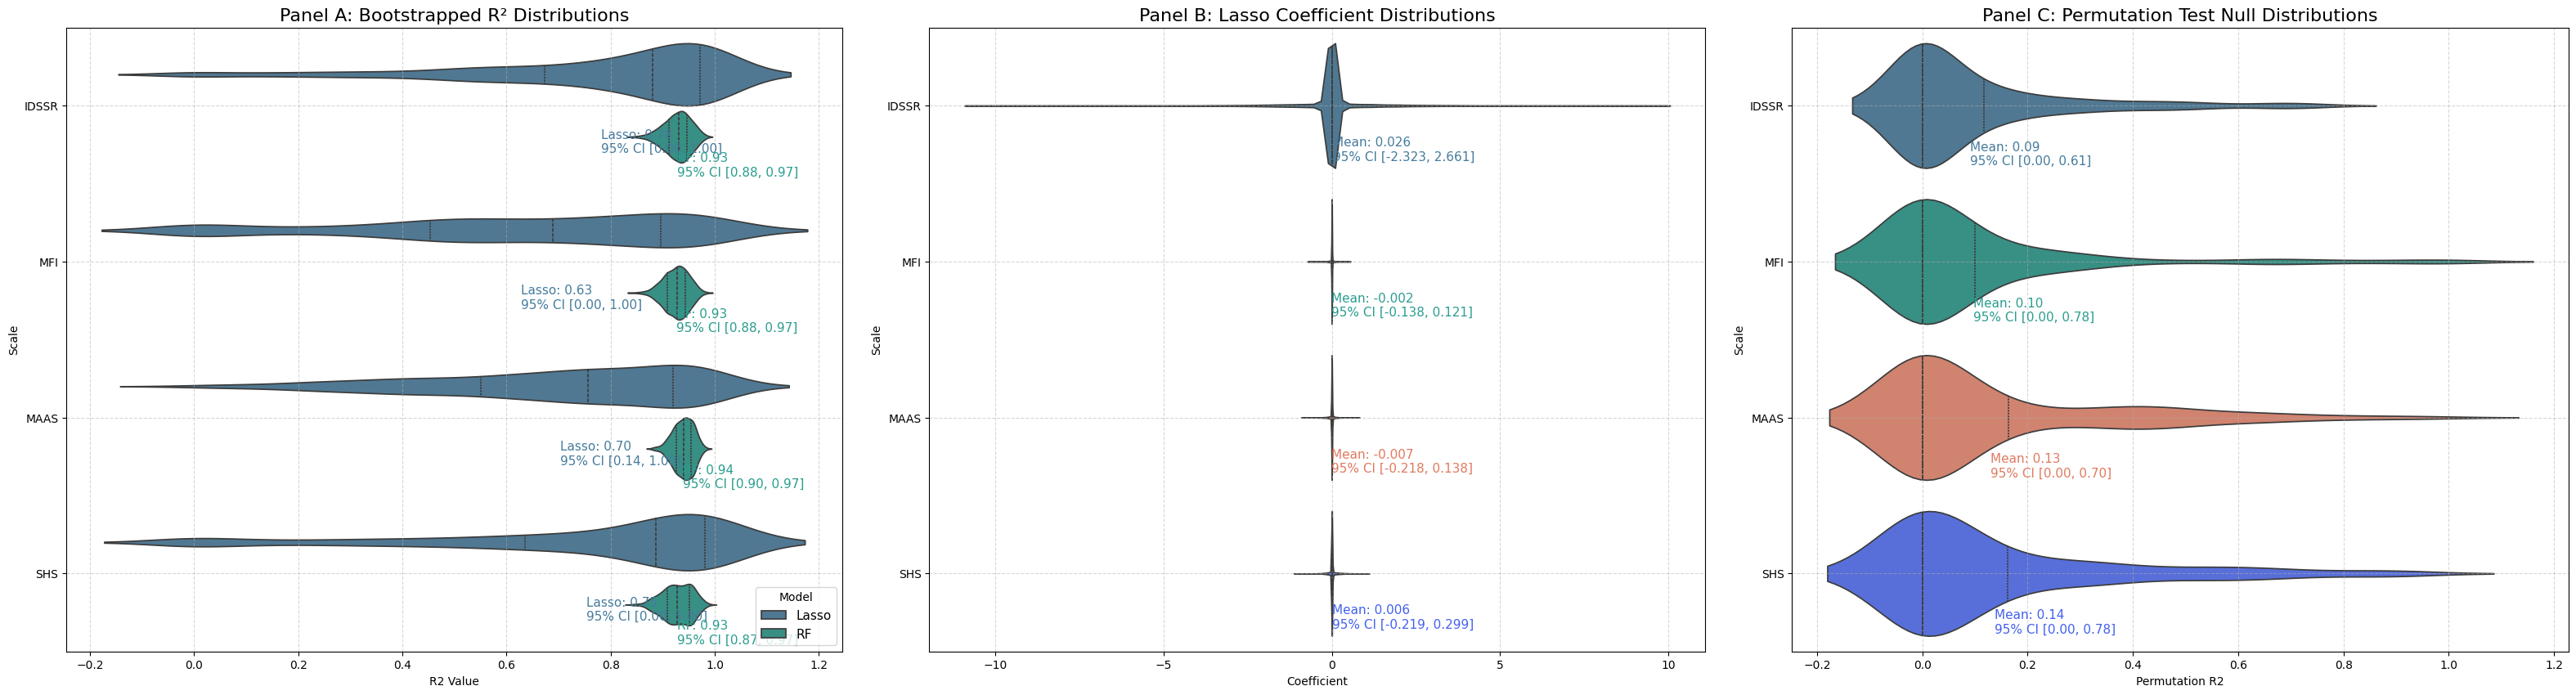

In [50]:
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap
from joblib import Parallel, delayed

scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
lasso_coef_list = []
perm_r2_list = []

# --- Kambo Scalar Outcome ML: Debugging and Enhancement ---

from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import textwrap
from joblib import Parallel, delayed

scale_color_palette = {
    'IDSSR': {'lasso': '#457b9d', 'perm': '#a8dadc', 'mdi': '#1d3557', 'pdp': '#457b9d'},
    'MFI': {'lasso': '#2a9d8f', 'perm': '#99d9c9', 'mdi': '#1f776c', 'pdp': '#2a9d8f'},
    'MAAS': {'lasso': '#e07a5f', 'perm': '#f4a261', 'mdi': '#cc5c47', 'pdp': '#e07a5f'},
    'SHS': {'lasso': '#4361ee', 'perm': '#b5c0f9', 'mdi': '#2c3791', 'pdp': '#4361ee'}
}

outcome_variables = {
    'IDSSR': 'Outcome_Delta_IDSSR',
    'MFI': 'Outcome_Delta_MFI',
    'MAAS': 'Outcome_Delta_MAAS',
    'SHS': 'Outcome_Delta_SHS'
}

final_top_predictors_all_v2 = {}
r2_bootstrap_list = []
lasso_coef_list = []
perm_r2_list = []

# Debug step: Print columns for each outcome before fitting
for label, column_name in outcome_variables.items():
    y = df[column_name]
    leakage_vars = leakage_cols
    X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
    X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
    print(f"\n--- Debug: Predictors for {label} ({column_name}) ---")
    print(f"Shape: {X_current.shape}")
    print("Columns:", list(X_current.columns))
    print(f"Missingness (sum):\n{X_current.isnull().sum()}\n")
    # Optionally: print top few rows
    print("Sample rows:", X_current.head())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_current)

    # Bootstrap (fix: collect RF bootstrap just like Lasso)
    for _ in range(500):
        sample_idx = np.random.choice(len(X_current), size=len(X_current), replace=True)
        X_sample = X_scaled[sample_idx]
        y_sample = y.iloc[sample_idx]
        lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
        lasso.fit(X_sample, y_sample)
        lasso_r2 = lasso.score(X_sample, y_sample)
        r2_bootstrap_list.append({"Scale": label, "R2 Value": lasso_r2, "Model": "Lasso"})
        coef_series = pd.Series(lasso.coef_, index=X_current.columns)
        coef_series['Scale'] = label
        lasso_coef_list.append(coef_series)
        # RF
        rf = RandomForestRegressor(n_estimators=500, random_state=42)
        rf.fit(X_sample, y_sample)
        rf_r2 = rf.score(X_sample, y_sample)
        r2_bootstrap_list.append({"Scale": label, "R2 Value": rf_r2, "Model": "RF"})

    # Parallel permutation R2 (keep as is)
    def permuted_lasso_score(X_sample, y_sample):
        permuted_y = np.random.permutation(y_sample)
        lasso_perm = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
        lasso_perm.fit(X_sample, permuted_y)
        return lasso_perm.score(X_sample, permuted_y)
    perm_r2_results = Parallel(n_jobs=-1)(delayed(permuted_lasso_score)(X_scaled, y) for _ in range(100))
    for perm_r2 in perm_r2_results:
        perm_r2_list.append({"Scale": label, "Permutation R2": perm_r2})

    # Print Lasso nonzero features
    lasso = LassoCV(cv=5, random_state=42, max_iter=20000, n_alphas=20, n_jobs=-1)
    lasso.fit(X_scaled, y)
    lasso_coef = pd.Series(lasso.coef_, index=X_current.columns)
    lasso_nonzero = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
    print(f"Nonzero Lasso features for {label}: {lasso_nonzero}")
    # Print top RF features
    rf = RandomForestRegressor(n_estimators=500, random_state=42)
    rf.fit(X_current, y)
    rf_importance = pd.Series(rf.feature_importances_, index=X_current.columns).sort_values(ascending=False)
    print(f"Top RF features for {label}: {rf_importance.head(10)}")

# Construct Lasso Coef DataFrame
lasso_coef_df = pd.DataFrame(lasso_coef_list)
lasso_coef_df = lasso_coef_df.melt(id_vars=['Scale'], var_name="Feature", value_name="Coefficient")

r2_bootstrap_df = pd.DataFrame(r2_bootstrap_list)
perm_r2_df = pd.DataFrame(perm_r2_list)

# Summarize R² for each outcome/model
summary_r2 = []
for scale in r2_bootstrap_df['Scale'].unique():
    for model in r2_bootstrap_df['Model'].unique():
        vals = r2_bootstrap_df.loc[(r2_bootstrap_df['Scale'] == scale) & (r2_bootstrap_df['Model'] == model), 'R2 Value'].dropna()
        if len(vals) > 0:
            mean = vals.mean()
            ci_lower, ci_upper = np.percentile(vals, [2.5, 97.5])
            summary_r2.append({
                "Scale": scale,
                "Model": model,
                "N": len(vals),
                "Mean R2": mean,
                "95% CI Lower": ci_lower,
                "95% CI Upper": ci_upper
            })
r2_summary_df = pd.DataFrame(summary_r2)
print(r2_summary_df)

# Optionally: Save to Google Drive
r2_summary_df.to_csv("continuous_model_r2_summary.csv", index=False)
!cp continuous_model_r2_summary.csv "/content/drive/My Drive/Kambo/"

# Color map for scales
scale_color_map = {k: v['lasso'] for k, v in scale_color_palette.items()}

model_palette = {'Lasso': '#457b9d', 'RF': '#2a9d8f'}

# --- Publication-ready annotated multiplot ---
def plot_validation_figure_with_lasso_and_permutation(r2_bootstrap_df, lasso_coef_df, perm_r2_df, model_palette, scale_color_map):
    fig, axes = plt.subplots(1, 3, figsize=(32, 9))
    # Panel A: R2 violin plot
    sns.violinplot(
        data=r2_bootstrap_df,
        x='R2 Value',
        y='Scale',
        hue='Model',
        palette=model_palette,
        split=False,
        ax=axes[0],
        inner="quartile"
    )
    axes[0].set_title("Panel A: Bootstrapped R² Distributions", fontsize=16)
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend(loc='lower right', fontsize=11, title="Model")

    # Annotate Panel A
    for i, scale in enumerate(r2_bootstrap_df['Scale'].unique()):
        for j, model in enumerate(r2_bootstrap_df['Model'].unique()):
            vals = r2_bootstrap_df.loc[(r2_bootstrap_df['Scale'] == scale) & (r2_bootstrap_df['Model'] == model), 'R2 Value']
            if not vals.empty:
                mean = vals.mean()
                ci = np.percentile(vals, [2.5, 97.5])
                axes[0].text(mean, i + 0.3 + 0.15*j, f"{model}: {mean:.2f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]", color=model_palette[model], fontsize=11)

    # Panel B: Lasso Coefficient Distribution
    sns.violinplot(
        data=lasso_coef_df,
        x='Coefficient',
        y='Scale',
        palette=scale_color_map,
        ax=axes[1],
        inner="quartile"
    )
    axes[1].set_title("Panel B: Lasso Coefficient Distributions", fontsize=16)
    axes[1].grid(True, linestyle='--', alpha=0.5)
    # Annotate Panel B
    for i, scale in enumerate(lasso_coef_df['Scale'].unique()):
        vals = lasso_coef_df.loc[lasso_coef_df['Scale'] == scale, 'Coefficient']
        mean = vals.mean()
        ci = np.percentile(vals, [2.5, 97.5])
        axes[1].text(mean, i + 0.35, f"Mean: {mean:.3f}\n95% CI [{ci[0]:.3f}, {ci[1]:.3f}]", color=scale_color_map[scale], fontsize=11)

    # Panel C: Permutation Test Null Distributions
    sns.violinplot(
        data=perm_r2_df,
        x='Permutation R2',
        y='Scale',
        palette=scale_color_map,
        ax=axes[2],
        inner="quartile"
    )
    axes[2].set_title("Panel C: Permutation Test Null Distributions", fontsize=16)
    axes[2].grid(True, linestyle='--', alpha=0.5)
    # Annotate Panel C
    for i, scale in enumerate(perm_r2_df['Scale'].unique()):
        vals = perm_r2_df.loc[perm_r2_df['Scale'] == scale, 'Permutation R2']
        mean = vals.mean()
        ci = np.percentile(vals, [2.5, 97.5])
        axes[2].text(mean, i + 0.38, f"Mean: {mean:.2f}\n95% CI [{ci[0]:.2f}, {ci[1]:.2f}]", color=scale_color_map[scale], fontsize=11)

    plt.tight_layout(pad=2.5)
    plt.savefig("validation_summary_figure_extended_annotated.png", dpi=600, bbox_inches="tight")
    !cp validation_summary_figure_extended_annotated.png "/content/drive/My Drive/Kambo/"
    plt.close(fig)
    return fig

plot_validation_figure_with_lasso_and_permutation(r2_bootstrap_df, lasso_coef_df, perm_r2_df, model_palette, scale_color_map)


cp: cannot stat 'model_validation_balanced.png': No such file or directory
cp: cannot stat 'ryff_bootstrap_metrics_balanced.csv': No such file or directory
cp: cannot stat 'ryff_lasso_coefficients_bootstrap_balanced.csv': No such file or directory
Bootstrapped metrics summary:
            AUC                                                        \
          count      mean           std       min  25%  50%  75%  max   
Model                                                                   
Logistic  500.0  0.995486  1.076581e-02  0.931818  1.0  1.0  1.0  1.0   
RF        500.0  1.000000  1.721673e-17  1.000000  1.0  1.0  1.0  1.0   

         Accuracy                                              Precision  \
            count     mean       std   min  25%  50%  75%  max     count   
Model                                                                      
Logistic    500.0  0.98396  0.033421  0.82  1.0  1.0  1.0  1.0     500.0   
RF          500.0  1.00000  0.000000  1.00  1.0  1.0

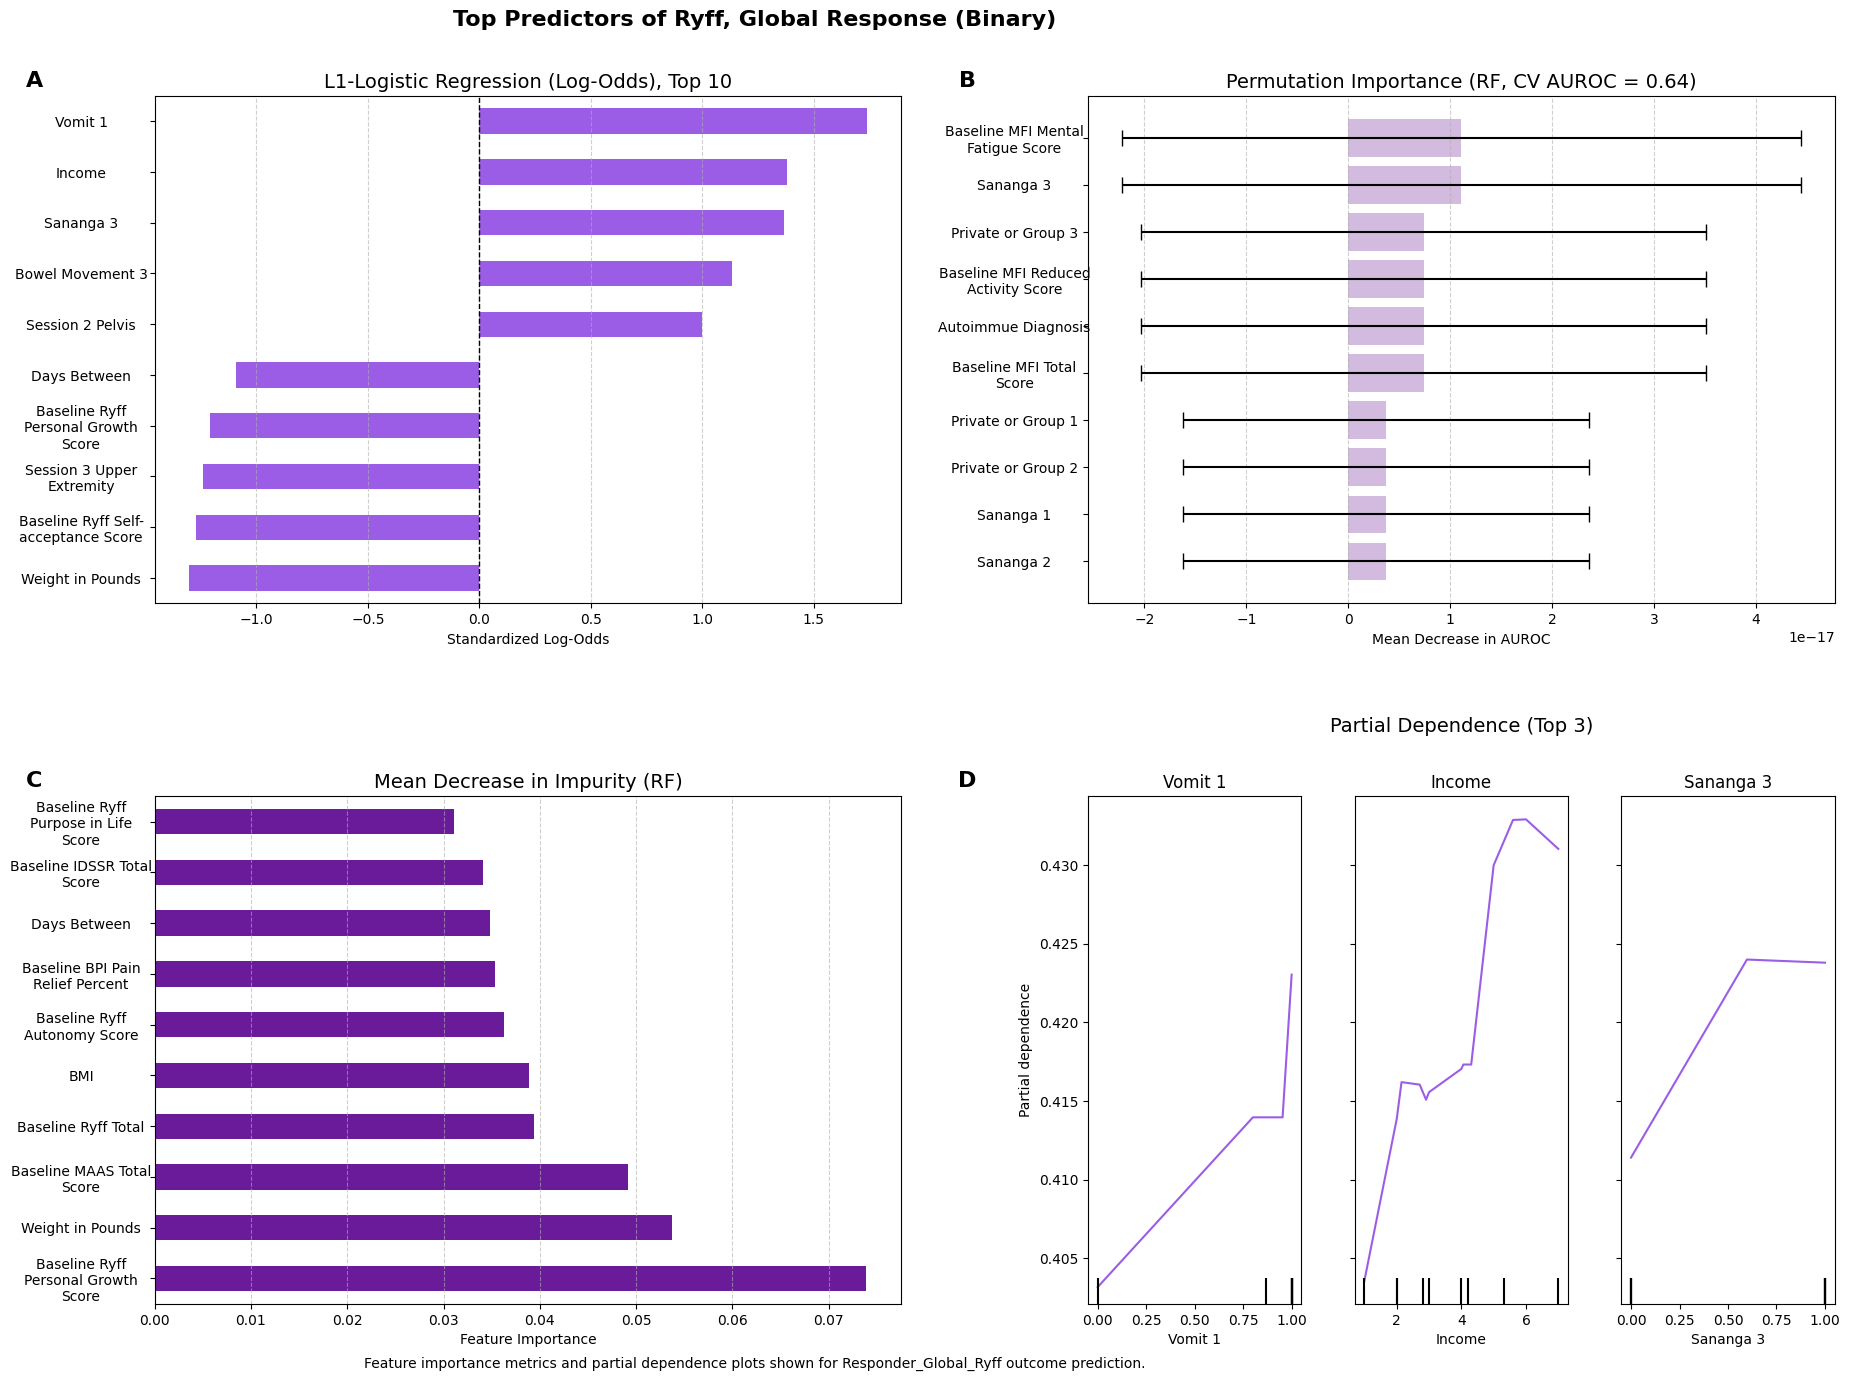

In [38]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns

# --- Color Palette ---
palette = {
    'lasso': '#9b5de5',       # Main (Lasso/logistic)
    'perm': '#cdb4db',        # Permutation
    'mdi': '#6a1b9a',         # MDI (Random Forest)
    'pdp': '#9b5de5'          # PDP
}

# --- Load label map ---
label_map_df = pd.read_csv('/content/drive/MyDrive/Kambo/label_map_cleaned.csv', index_col=False)
label_map = dict(zip(label_map_df['Original Column'], label_map_df['Cleaned Label']))

def beautify(labels):
    return [label_map.get(l, l) for l in labels]

# --- Specify outcome and features ---
outcome_label = 'Responder_Global_Ryff'
leakage_vars = leakage_cols

X = df.drop(columns=[col for col in leakage_vars if col in df.columns])
X_current = X.select_dtypes(include=['float64', 'int64']).drop(columns=['AnonID'], errors='ignore')
y = df[outcome_label]

# --- Standardize X ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_current)

# --- Bootstrapping function (unchanged) ---
def single_bootstrap_iteration(X, y, random_seed):
    np.random.seed(random_seed)
    idx = np.random.choice(len(X), size=len(X), replace=True)
    X_sample = X[idx, :]
    y_sample = y.iloc[idx]

    logistic = LogisticRegressionCV(
        Cs=10, cv=5, penalty='l1', solver='saga', max_iter=10000,
        n_jobs=-1, scoring='roc_auc', random_state=42, class_weight='balanced'
    )
    logistic.fit(X_sample, y_sample)
    y_pred_prob = logistic.predict_proba(X_sample)[:, 1]
    y_pred = (y_pred_prob > 0.5).astype(int)

    rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1, class_weight='balanced')
    rf.fit(X_sample, y_sample)
    rf_pred_prob = rf.predict_proba(X_sample)[:, 1]
    rf_pred = (rf_pred_prob > 0.5).astype(int)

    metrics = []
    for model, probs, preds, name in [
        (logistic, y_pred_prob, y_pred, 'Logistic'),
        (rf, rf_pred_prob, rf_pred, 'RF')
    ]:
        metrics.append({
            'Model': name,
            'AUC': roc_auc_score(y_sample, probs),
            'Accuracy': accuracy_score(y_sample, preds),
            'Precision': precision_score(y_sample, preds, zero_division=0),
            'Recall': recall_score(y_sample, preds, zero_division=0)
        })
    lasso_coefs = None
    if hasattr(logistic, 'coef_'):
        lasso_coefs = logistic.coef_[0]
    return metrics, lasso_coefs

n_iterations = 500
seeds = np.random.randint(0, 1e6, size=n_iterations)

results = Parallel(n_jobs=-1)(
    delayed(single_bootstrap_iteration)(X_scaled, y, seed) for seed in seeds
)
metrics_bootstrap = [item[0] for item in results]
coefs_bootstrap = [item[1] for item in results]

# --- Flatten and create DataFrames ---
metrics_flat = [dict(**m, Iteration=i) for i, m_list in enumerate(metrics_bootstrap) for m in m_list]
metrics_df = pd.DataFrame(metrics_flat)

coefs_matrix = np.array([c for c in coefs_bootstrap if c is not None])
coefs_df = pd.DataFrame(coefs_matrix, columns=beautify(X_current.columns))
coefs_df['Iteration'] = np.arange(len(coefs_df))

# --- Fit on full data for importances ---
logistic_full = LogisticRegressionCV(
    Cs=10, cv=5, penalty='l1', solver='saga', max_iter=10000,
    n_jobs=-1, scoring='roc_auc', random_state=42
)
logistic_full.fit(X_scaled, y)

rf_full = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf_full.fit(X_current, y)

# Compute cross-validated AUROC for RF
rf_auc = cross_val_score(rf_full, X_current, y, cv=5, scoring='roc_auc').mean()

# Permutation importance (RF, AUROC)
perm = permutation_importance(
    rf_full, X_current, y, n_repeats=30, random_state=42, scoring='roc_auc', n_jobs=-1
)
perm_importances = pd.Series(perm.importances_mean, index=beautify(X_current.columns)).sort_values(ascending=False)
perm_stds = pd.Series(perm.importances_std, index=beautify(X_current.columns))[perm_importances.index]

# MDI
mdi_importances = pd.Series(rf_full.feature_importances_, index=beautify(X_current.columns)).sort_values(ascending=False)

# Lasso coefficients (log-odds)
lasso_coefs = pd.Series(logistic_full.coef_[0], index=beautify(X_current.columns))
lasso_nonzero = lasso_coefs[lasso_coefs.abs() > 0.01].sort_values(key=abs, ascending=False)
lasso_top10 = lasso_nonzero.head(10)

# --- Partial Dependence (top 3 features from lasso, pretty labels) ---
top_features_raw = [k for k, v in label_map.items() if v in lasso_top10.index][:3]

import textwrap

def wrap_labels(ax, width=20, pad=49.5):
    """Wraps long y-axis labels on the given matplotlib axis."""
    labels = ax.get_yticklabels()
    new_labels = []
    for label in labels:
        text = label.get_text()
        wrapped = '\n'.join(textwrap.wrap(text, width, break_long_words=False))
        new_labels.append(wrapped)
    ax.set_yticks(range(len(new_labels)))
    ax.set_yticklabels(new_labels, ha='center')
    ax.tick_params(axis='y', pad=pad)

fig, axes = plt.subplots(2, 2, figsize=(24, 14))
fig.suptitle(f"Top Predictors of Ryff, Global Response (Binary)", fontsize=16, fontweight='bold')

# --- Panel A: L1-logistic (Top 10, pretty labels) ---
if not lasso_top10.empty:
    lasso_top10.sort_values().plot(kind='barh', ax=axes[0, 0], color=palette['lasso'])
    axes[0, 0].set_title("L1-Logistic Regression (Log-Odds), Top 10", fontsize=14)
else:
    axes[0, 0].text(0.5, 0.5, 'No Nonzero Lasso Coefficients', ha='center', va='center')
    axes[0, 0].set_axis_off()
axes[0, 0].axvline(x=0, color='black', linestyle='--', linewidth=1)
axes[0, 0].set_xlabel('Standardized Log-Odds')
axes[0, 0].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[0, 0].set_ylabel('')

# --- Panel B: Permutation Importance (RF, with CIs, wrap, and annotations) ---
perm_top = perm_importances.head(10)
perm_top_std = perm_stds.loc[perm_top.index]
axes[0, 1].barh(perm_top.index, perm_top.values, xerr=perm_top_std.values,
                color=palette['perm'], alpha=0.9, capsize=6)
axes[0, 1].set_title(f'Permutation Importance (RF, CV AUROC = {rf_auc:.2f})', fontsize=14)
axes[0, 1].invert_yaxis()
axes[0, 1].set_xlabel('Mean Decrease in AUROC')
axes[0, 1].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[0, 1].set_ylabel('')

# Numeric annotations on bars
#for i, (value, label) in enumerate(zip(perm_top.values, perm_top.index)):
#    axes[0, 1].text(value + perm_top_std.values[i], i + 0.15,
#                    f'{value:.4f}', va='center', ha='left', fontsize=8, color='black')

# --- Panel C: MDI (RF) ---
mdi_top = mdi_importances.head(10)
mdi_top.sort_values().plot(kind='barh', ax=axes[1, 0], color=palette['mdi'])
axes[1, 0].set_title('Mean Decrease in Impurity (RF)', fontsize=14)
axes[1, 0].invert_yaxis()
axes[1, 0].set_xlabel('Feature Importance')
axes[1, 0].grid(True, axis='x', linestyle='--', alpha=0.6)
axes[1, 0].set_ylabel('')

# --- Panel D: Partial Dependence (Y-position tweak and label wrapping) ---
reverse_label_map = {v: k for k, v in label_map.items()}
candidate_raw_features = [reverse_label_map.get(pretty, pretty) for pretty in lasso_top10.index]
top_features_raw = [feat for feat in candidate_raw_features if feat in X_current.columns][:3]

if top_features_raw:
    pdp_disp = PartialDependenceDisplay.from_estimator(
        rf_full, X_current, top_features_raw, ax=axes[1, 1], kind='average',
        line_kw={'color': palette['pdp']}
    )
    axes[1, 1].set_title("Partial Dependence (Top 3)", y=1.11, fontsize=14)  # y moves title up
    for ax, feature_raw in zip(pdp_disp.axes_.ravel(), top_features_raw):
        pretty = label_map.get(feature_raw, feature_raw)
        ax.set_xlabel(pretty)
        ax.set_title(pretty, fontsize=12)
else:
    axes[1, 1].text(0.5, 0.5, 'No Partial Dependence Available', ha='center', va='center')
    axes[1, 1].set_axis_off()

# --- Label wrapping for all y-axes ---
wrap_labels(axes[0, 0])
wrap_labels(axes[0, 1])
wrap_labels(axes[1, 0])

# --- Panel labels ---
panel_labels = ['A', 'B', 'C', 'D']
positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
for label, (i, j) in zip(panel_labels, positions):
    axes[i, j].text(-0.15, 1.05, label, transform=axes[i, j].transAxes,
                    fontsize=16, fontweight='bold', va='top', ha='right')

plt.tight_layout(pad=2.5)  # Increase pad for more space
plt.subplots_adjust(left=0.25, right=0.95, wspace=0.25, hspace=0.38)  # Adjust as desired
plt.figtext(0.5, 0.01, f"Feature importance metrics and partial dependence plots shown for {outcome_label} outcome prediction.",
            wrap=True, horizontalalignment='center', fontsize=10)

figpath = "model_validation.png"
plt.savefig(figpath, dpi=600, bbox_inches='tight')
!cp model_validation_balanced.png "/content/drive/My Drive/Kambo/"

# --- Save raw bootstrap and coefficient values (with pretty labels) ---
metrics_df.to_csv("ryff_bootstrap_metrics_balanced.csv", index=False)
!cp ryff_bootstrap_metrics_balanced.csv "/content/drive/My Drive/Kambo/"
coefs_df.to_csv("ryff_lasso_coefficients_bootstrap_balanced.csv", index=False)
!cp ryff_lasso_coefficients_bootstrap_balanced.csv "/content/drive/My Drive/Kambo/"

# --- Print summary tables (pretty labels) ---
print("Bootstrapped metrics summary:")
print(metrics_df.groupby("Model")[['AUC', 'Accuracy', 'Precision', 'Recall']].describe())
print("\nTop L1-Logistic features (log-odds):")
print(lasso_top10)
print("\nTop RF permutation importances:")
print(perm_importances.head(10))


In [42]:
import pandas as pd

# Load bootstrap metrics for balanced and non-balanced models
balanced_metrics = pd.read_csv('/content/drive/MyDrive/Kambo/ryff_bootstrap_metrics_balanced.csv')
nonbal_metrics = pd.read_csv('/content/drive/MyDrive/Kambo/Responder_Global_Ryff_bootstrap_metrics.csv')

# Group by model and summarize metrics (mean, 2.5%, 97.5%)
def metric_summary(df):
    summary = df.groupby('Model').agg({
        'AUC': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Accuracy': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Precision': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)],
        'Recall': ['mean', lambda x: x.quantile(0.025), lambda x: x.quantile(0.975)]
    })
    summary.columns = ['_'.join(filter(None, col)).replace('<lambda_0>', '2.5%').replace('<lambda_1>', '97.5%') for col in summary.columns]
    return summary

balanced_summary = metric_summary(balanced_metrics)
nonbal_summary = metric_summary(nonbal_metrics)

balanced_summary.to_csv("balanced_summary.csv", index=False)
!cp balanced_summary.csv "/content/drive/My Drive/Kambo/"
nonbal_summary.to_csv("nonbal_summary.csv", index=False)
!cp nonbal_summary.csv "/content/drive/My Drive/Kambo/"


In [47]:
# Load coefficients
bal_lasso = pd.read_csv('/content/drive/MyDrive/Kambo/ryff_lasso_coefficients_bootstrap_balanced.csv')
nonbal_lasso = pd.read_csv('/content/drive/MyDrive/Kambo/Responder_Global_Ryff_lasso_coefficients_bootstrap.csv')

# Summarize the mean and CI for each feature
def coef_summary(df):
    feat_means = df.drop(columns=['Iteration', 'Scale'], errors='ignore').mean()
    feat_ci2p5 = df.drop(columns=['Iteration', 'Scale'], errors='ignore').quantile(0.025)
    feat_ci97p5 = df.drop(columns=['Iteration', 'Scale'], errors='ignore').quantile(0.975)
    return pd.DataFrame({
        "Mean": feat_means,
        "2.5%": feat_ci2p5,
        "97.5%": feat_ci97p5
    }).sort_values("Mean", key=abs, ascending=False)

bal_coef_summary = coef_summary(bal_lasso)
nonbal_coef_summary = coef_summary(nonbal_lasso)
bal_coef_summary.to_csv("bal_coef_summary.csv", index=False)
!cp bal_coef_summary.csv "/content/drive/My Drive/Kambo/"
nonbal_coef_summary.to_csv("nonbal_coef_summary.csv", index=False)
!cp nonbal_coef_summary.csv "/content/drive/My Drive/Kambo/"
bal_coef_summary.head(10), nonbal_coef_summary.head(10)


(                                         Mean      2.5%         97.5%
 Baseline Ryff Personal Growth Score -1.061455 -3.278660  0.000000e+00
 Income                               0.900802  0.000000  2.934646e+00
 Weight in Pounds                    -0.859164 -2.587439  0.000000e+00
 Bowel Movement 3                     0.804810  0.000000  2.692769e+00
 Vomit 1                              0.741140  0.000000  2.448314e+00
 Sananga 3                            0.732407  0.000000  2.653216e+00
 Baseline Ryff Self-acceptance Score -0.722066 -2.644932  0.000000e+00
 Session 3 Head                      -0.705586 -2.407276  0.000000e+00
 Days Between                        -0.664034 -2.649238  0.000000e+00
 Session 3 Upper Extremity           -0.554382 -1.921509  4.269822e-07,
                                          Mean      2.5%     97.5%
 Baseline Ryff Personal Growth Score -1.085419 -3.355806  0.000000
 Income                               0.976496  0.000000  2.868748
 Weight in Pounds

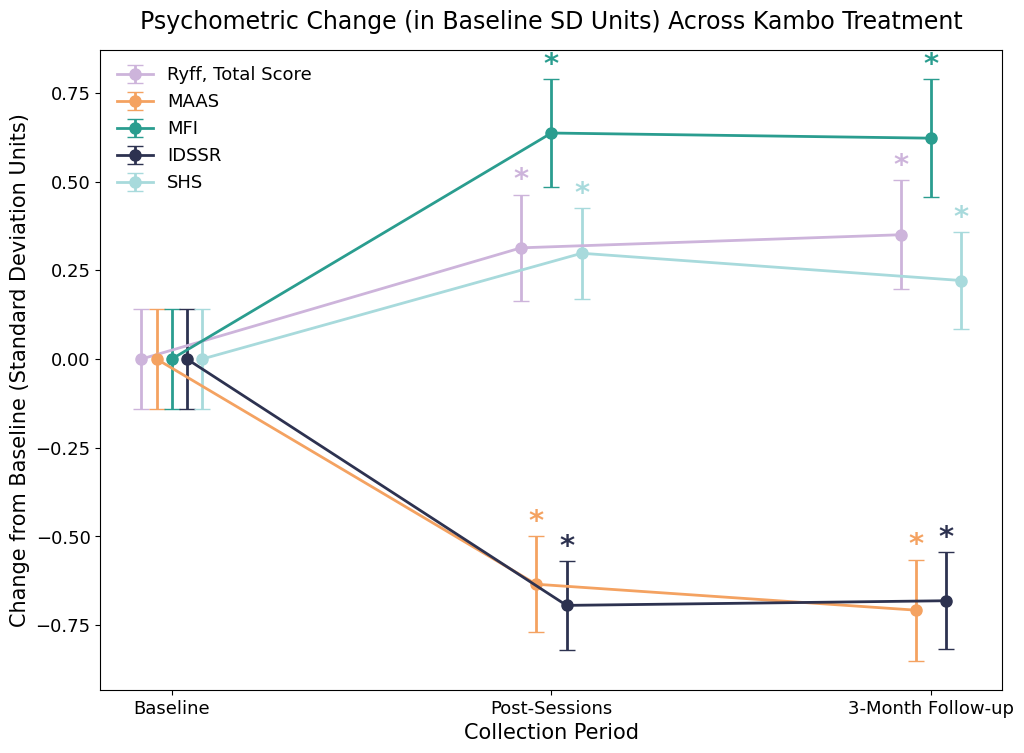

In [28]:
from scipy.stats import ttest_rel, sem

# Define the color palette
color_map = {
    "Ryff, Total Score": '#cdb4db',   # Lavender
    "MAAS": '#f4a261',                # Orange
    "MFI": '#2a9d8f',                 # Aqua
    "SHS": '#a8dadc',               # Robin's egg blue
    "IDSSR": '#2d3250',                 # Navy blue
}

# Timepoint and label mapping
scale_map = {
    "Ryff, Total Score": ['PRE_RYFF_Total', 'RYFF_Total_POST', 'RYFF_Total_3MONTHSPOST'],
    "MAAS": ['PRE_MAAS_Total', 'MAAS_Total_POST', 'MAAS_Total_3MONTHSPOST'],
    "MFI": ['PRE_MFI_TotalScore', 'MFI_TotalScore_POST', 'MFI_TotalScore_3MONTHSPOST'],
    "IDSSR": ['PRE_IDS_TotalScore', 'IDS_TotalScore_POST', 'IDS_TotalScore_3MONTHSPOST'],
    "SHS": ['PRE_SHS_TotalScore', 'SHS_TotalScore_POST', 'SHS_TotalScore_3MONTHSPOST'],
}
timepoints = ['Baseline', 'Post-Sessions', '3-Month Follow-up']

# Containers for group stats
mean_scores = {}
sem_scores = {}
z_all = {}
scale_names = list(scale_map.keys())
offsets = np.linspace(-0.080, 0.080, len(scale_names))  # Evenly spaced offsets

# For each scale, compute Z-scores relative to baseline
for scale, cols in scale_map.items():
    data = df[cols].copy()
    baseline_mean = data[cols[0]].mean()
    baseline_sd = data[cols[0]].std()
    z_data = (data - baseline_mean) / baseline_sd
    z_all[scale] = z_data
    mean_scores[scale] = z_data.mean().values
    sem_scores[scale] = z_data.sem().values

# --- Plotting ---
fig, ax = plt.subplots(figsize=(11, 8))

time_idx = np.arange(len(timepoints))
for i, scale in enumerate(scale_names):
    ax.errorbar(
        time_idx + offsets[i], mean_scores[scale], yerr=sem_scores[scale],
        label=scale, color=color_map[scale],
        marker='o', markersize=8, linewidth=2, capsize=6,
    )

    # Add significance stars (update star placement to use offset)
    z = z_all[scale]
    for t, idx in zip(['Post-Sessions', '3-Month Follow-up'], [1, 2]):
        p = ttest_rel(z.iloc[:, 0], z.iloc[:, idx], nan_policy='omit').pvalue
        if p < 0.05:
            y_star = mean_scores[scale][idx] + sem_scores[scale][idx] + 0.001
            ax.text(time_idx[idx] + offsets[i], y_star, '*', ha='center', va='bottom',
                    color=color_map[scale], fontsize=21, fontweight='bold')

ax.set_ylabel('Change from Baseline (Standard Deviation Units)', fontsize=15)
ax.set_xlabel('Collection Period', fontsize=15)
ax.set_title('Psychometric Change (in Baseline SD Units) Across Kambo Treatment', fontsize=17, pad=15)
ax.set_xticks(time_idx)
ax.set_xticklabels(timepoints, fontsize=13)
ax.tick_params(axis='both', labelsize=13)
ax.legend(frameon=False, loc='upper left', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(left=0.16, right=0.98, top=0.91, bottom=0.11)
figpath = "psychometric_change_zscore.png"
plt.savefig(figpath, dpi=600, bbox_inches='tight')
!cp {figpath} "/content/drive/My Drive/Kambo/"

# --- Optional: Export values to CSV for reproducibility ---
all_means = pd.DataFrame(mean_scores, index=timepoints)
all_sems = pd.DataFrame(sem_scores, index=timepoints)
all_means.to_csv("psychometric_change_zscore_means.csv")
all_sems.to_csv("psychometric_change_zscore_sems.csv")
!cp psychometric_change_zscore_means.csv "/content/drive/My Drive/Kambo/"
!cp psychometric_change_zscore_sems.csv "/content/drive/My Drive/Kambo/"

plt.show()
